# Soil Moisture and Landslide Risk Analysis using Sentinel-1 SAR Imagery

**Author:** Elia Toma  
**Objective:** This analysis aims to estimate volumetric soil moisture by comparing Synthetic Aperture Radar (SAR) backscatter across different time intervals. Detecting pre-conditional soil saturation allows us to evaluate the impending risk of landslide and debris-flow events.  
**Data Sources:** [Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/) — Sentinel-1 data.

In [1]:
import os
from dotenv import load_dotenv
from sentinelhub import (
    SHConfig, SentinelHubRequest, DataCollection,
    MimeType, BBox, CRS, bbox_to_dimensions
)
import numpy as np
import matplotlib.pyplot as plt
 
# Enter your CDSE credentials here
config = SHConfig()

# Load the .env file into memory
load_dotenv()

# Retrieve variables and assign them to the configuration
config.sh_client_id     = os.getenv('SH_CLIENT_ID')
config.sh_client_secret = os.getenv('SH_CLIENT_SECRET')

config.sh_base_url      = 'https://sh.dataspace.copernicus.eu'
config.sh_token_url     = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token'

DataCollection.SENTINEL1_IW.define_from(
    name='s1',
    service_url='https://sh.dataspace.copernicus.eu'
)

c:\Users\Elia\Desktop\Cassini Challenge\Codice\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<DataCollection.s1: DataCollectionDefinition(
  api_id: sentinel-1-grd
  catalog_id: sentinel-1-grd
  wfs_id: DSS3
  service_url: https://sh.dataspace.copernicus.eu
  collection_type: Sentinel-1
  sensor_type: C-SAR
  processing_level: GRD
  swath_mode: IW
  polarization: DV
  resolution: HIGH
  orbit_direction: BOTH
  bands: (Band(name='VV', units=(<Unit.LINEAR_POWER: 'LINEAR_POWER'>,), output_types=(<class 'numpy.float32'>,)), Band(name='VH', units=(<Unit.LINEAR_POWER: 'LINEAR_POWER'>,), output_types=(<class 'numpy.float32'>,)))
  metabands: (Band(name='localIncidenceAngle', units=(<Unit.DN: 'DN'>,), output_types=(<class 'numpy.float32'>,)), Band(name='scatteringArea', units=(<Unit.DN: 'DN'>,), output_types=(<class 'numpy.float32'>,)), Band(name='shadowMask', units=(<Unit.DN: 'DN'>,), output_types=(<class 'bool'>,)), Band(name='dataMask', units=(<Unit.DN: 'DN'>,), output_types=(<class 'bool'>,)))
  is_timeless: False
  has_cloud_coverage: False
)>

In [2]:
# Format: [min_longitude, min_latitude, max_longitude, max_latitude]
bbox = BBox(bbox=[13.181231, 43.059295, 13.198180, 43.080588], crs=CRS.WGS84)
 
# Set spatial resolution: 20 metres per pixel (Sentinel-1 standard)
size = bbox_to_dimensions(bbox, resolution=20)
print(f'Image dimensions: {size[0]} x {size[1]} pixels')

Image dimensions: 72 x 117 pixels


In [3]:
# JavaScript evalscript executed on CDSE servers
# Retrieves VV and VH bands and returns a standard SAR false-colour composite
evalscript = """
//VERSION=3
function setup() {
  return {
    input:  [{ bands: ['VV', 'VH'] }],
    output: { bands: 3, sampleType: 'FLOAT32' }
  };
}
function evaluatePixel(sample) {
  // 1) Convert linear backscatter values to Decibels (dB)
  // Math.max is utilised to elegantly handle potential 'nodata' zero values
  let vv_db = 10 * Math.log10(Math.max(0.000001, sample.VV));
  let vh_db = 10 * Math.log10(Math.max(0.000001, sample.VH));
  // 2) Normalise negative dB SAR values for visual display range (0-1)
  let vv = Math.max(0, (vv_db + 25) / 25);
  let vh = Math.max(0, (vh_db + 35) / 25);
  
  return [vv, vh, vv / (vh + 0.001)];
}
"""

# Evalscript to retrieve solely the raw linear VV polarisation band
evalscript_raw = """
//VERSION=3
function setup() {
  return {
    input:  [{ bands: ['VV'] }],
    output: { bands: 1, sampleType: 'FLOAT32' }
  };
}
function evaluatePixel(sample) {
  return [sample.VV];
}
"""

## 2. SAR Data Extraction and Soil Moisture Principles

In this section, we extract the raw **Vertical-Vertical (VV) polarisation** band. 

- **What is the VV band?** It measures the radar signal transmitted and received in vertical alignment. It is exceptionally sensitive to the dielectric properties and surface roughness of bare soil.
- **Why use it for soil moisture?** As soil moisture increases, its dielectric constant rises, magnifying the radar backscatter returned to the satellite. Therefore, a stronger VV signal directly correlates with wetter, saturated geological layers.
- **What are Decibels (dB)?** Radar backscatter coefficients ($\gamma^0$) are initially provided on a linear power scale (very small floating-point numbers). We convert these to a logarithmic decibel (dB) scale ($dB = 10 \cdot \log_{10}(linear)$) to compress the vast dynamic range of radar returns, rendering geophysical differences comparable and mathematically tractable.

In [4]:
# --- 1. DEFINE ANALYSIS PERIODS ---
# Add any two date intervals to compare mathematically
period_A = ('2024-04-01', '2024-04-30')
period_B = ('2024-06-15', '2024-07-15')

# Store connection to avoid redundant declaration errors
data_col = DataCollection.s1

# Encapsulate raw VV retrieval into a reusable function
def fetch_mean_vv(time_interval):
    request_raw = SentinelHubRequest(
        evalscript=evalscript_raw,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=data_col,
                time_interval=time_interval,
                other_args={
                    'dataFilter': {'acquisitionMode': 'IW', 'polarization': 'DV'},
                    'processing': {'backCoeff': 'GAMMA0_TERRAIN', 'orthorectify': True}
                }
            )
        ],
        responses=[SentinelHubRequest.output_response('default', MimeType.TIFF)],
        bbox=bbox, size=size, config=config
    )
    
    vv_band = request_raw.get_data()[0]
    vv_db = 10 * np.log10(np.where(vv_band > 0, vv_band, 1e-10))
    return float(np.nanmean(vv_db))

# Fetch geophysical backscatter telemetry
print("Fetching SAR data for Period A...")
mean_A = fetch_mean_vv(period_A)
print("Fetching SAR data for Period B...")
mean_B = fetch_mean_vv(period_B)

# --- 2. AUTOMATED GEOPHYSICAL CLASSIFICATION ---
# The terrain emitting the higher (less negative) backscatter possesses greater moisture
if mean_A > mean_B:
    wet_period, dry_period = period_A, period_B
    vv_wet_db, vv_dry_db   = mean_A, mean_B
else:
    wet_period, dry_period = period_B, period_A
    vv_wet_db, vv_dry_db   = mean_B, mean_A

print("\n--- AUTOMATIC ALGORITHMIC CLASSIFICATION ---")
print(f"Detected Saturated (Wet) Period: {wet_period[0]} to {wet_period[1]}  (VV: {vv_wet_db:.2f} dB)")
print(f"Detected Baseline (Dry) Period:  {dry_period[0]} to {dry_period[1]}  (VV: {vv_dry_db:.2f} dB)")

Fetching SAR data for Period A...
Fetching SAR data for Period B...

--- AUTOMATIC ALGORITHMIC CLASSIFICATION ---
Detected Saturated (Wet) Period: 2024-04-01 to 2024-04-30  (VV: -9.15 dB)
Detected Baseline (Dry) Period:  2024-06-15 to 2024-07-15  (VV: -9.28 dB)


## 3. Soil Moisture Score Conversion

To translate our raw backscatter (dB) into a user-friendly mathematical 'Soil Moisture Score' (0-100), we employ an empirical thresholding approach tailored to rough terrain profiles.

- **Dry Threshold ($\text{dB}_{\text{dry}}$) = -20 dB:** Represents fully desaturated geological structures and dry bedrock.
- **Saturated Threshold ($\text{dB}_{\text{saturated}}$) = -5 dB:** Represents terrain at maximum water retention capacity, typical of pre-runoff or impending debris-flow conditions.

The linear scaling between these two physical limits yields our final saturation percentage index.

In [5]:
# Empirical reference thresholds
db_dry       = -20.0   # Backscatter (dB) for fully saturated soil
db_saturated = -5.0    # Backscatter (dB) for soil at maximum water retention

# Linearly map physical dB values to a 0-100% moisture risk index
score_wet = int(max(0, min(100, (vv_wet_db - db_dry) / (db_saturated - db_dry) * 100)))
score_dry = int(max(0, min(100, (vv_dry_db - db_dry) / (db_saturated - db_dry) * 100)))

print(f"Saturated Period Moisture Score: {score_wet}/100")
print(f"Baseline Period Moisture Score:  {score_dry}/100")

Saturated Period Moisture Score: 72/100
Baseline Period Moisture Score:  71/100


Rendering Saturated Terrain Visualisations...
Rendering Baseline Terrain Visualisations...
Generating Side-by-Side Comparison...


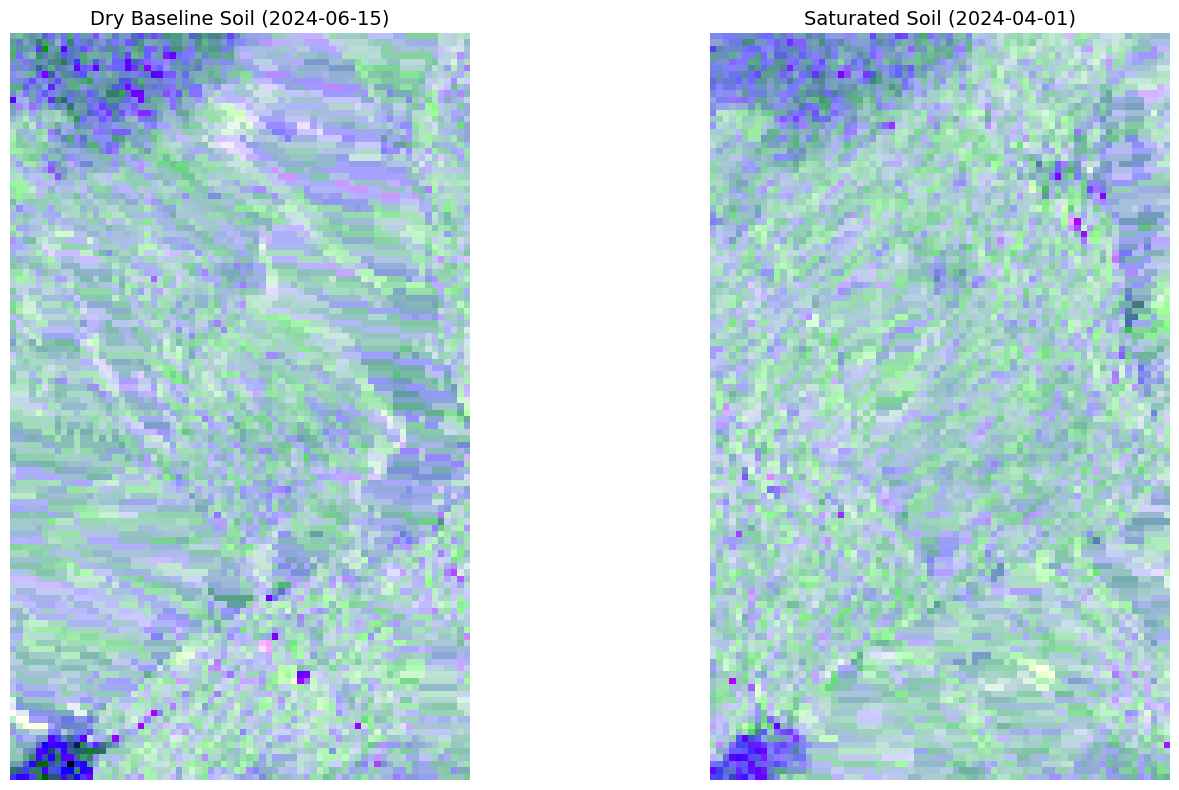

In [6]:
# Reusable function to render, plot and export visual composites
def fetch_and_save_visual(time_interval, filename, title):
    request = SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=data_col,
                time_interval=time_interval,
                other_args={
                    'dataFilter': {'acquisitionMode': 'IW', 'polarization': 'DV', 'resolution': 'HIGH'},
                    'processing': {'backCoeff': 'GAMMA0_TERRAIN', 'orthorectify': True}
                }
            )
        ],
        responses=[SentinelHubRequest.output_response('default', MimeType.TIFF)],
        bbox=bbox, size=size, config=config
    )
    img_display = np.clip(request.get_data()[0], 0, 1)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img_display)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()
    return img_display

# Estrarre le matrici immagine usando le label automatiche
print("Rendering Saturated Terrain Visualisations...")
img_wet = fetch_and_save_visual(wet_period, 'lame_rosse_SAR_saturated.png', f'SAR — Saturated Soil — {wet_period[0]}')

print("Rendering Baseline Terrain Visualisations...")
img_dry = fetch_and_save_visual(dry_period, 'lame_rosse_SAR_dry.png', f'SAR — Dry Baseline  — {dry_period[0]}')

print("Generating Side-by-Side Comparison...")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_dry)
axes[0].set_title(f'Dry Baseline Soil ({dry_period[0]})', fontsize=14)
axes[0].axis('off')

axes[1].imshow(img_wet)
axes[1].set_title(f'Saturated Soil ({wet_period[0]})', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('lame_rosse_SAR_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import json

# Compile backend results mapping dynamic temporal states correctly
results_dynamic = {
    'area':                        'Lame Rosse, Macerata(IT)',
    'source':                      'Copernicus Sentinel-1 GRD IW, CDSE API',
    'saturated_period':            f'{wet_period[0]} / {wet_period[1]}',
    'vv_mean_db_saturated':        round(vv_wet_db, 2),
    'soil_moisture_score_sat':     score_wet,
    'dry_period':                  f'{dry_period[0]} / {dry_period[1]}',
    'vv_mean_db_dry':              round(vv_dry_db, 2),
    'soil_moisture_score_dry':     score_dry,
    'delta_db':                    round(vv_wet_db - vv_dry_db, 2),
    'delta_score':                 score_wet - score_dry,
    'saturated_image':             'lame_rosse_SAR_saturated.png',
    'dry_image':                   'lame_rosse_SAR_dry.png',
    'comparison_image':            'lame_rosse_SAR_comparison.png'
}

with open('soil_moisture_results.json', 'w') as f:
    json.dump(results_dynamic, f, indent=2)

print('Geospatial analysis successfully completed, automatically labelled and exported to JSON.')

Geospatial analysis successfully completed, automatically labelled and exported to JSON.


## 4. Geospatial Grid Extraction for .NET Backend

This final section generates a highly granular spatial grid over the designated bounding box. By briefly re-fetching the raw SAR telemetry intrinsically linked to the critically saturated `wet_period`, we map discrete geographical coordinate pairs (Latitude/Longitude) to their precise physical pixel indices within the matrix. The algorithm individually evaluates specific backscatter profiles and transforms each discrete local reading into an operative soil moisture index (0-100%).

The resulting uniformly distributed multi-point tensor is instantly serialised into an incredibly lightweight, API-ready JSON manifest, specifically tailored for immediate asynchronous consumption by the associated .NET frontend services.

In [9]:
# --- 1. EXTRACT DYNAMIC SPATIAL BOUNDARIES ---
# Dynamically extract BBox parameters previously instantiated to prevent typographical shifts
LNG_MIN, LAT_MIN, LNG_MAX, LAT_MAX = list(bbox)
bbox_extents = (LAT_MIN, LAT_MAX, LNG_MIN, LNG_MAX)

# Note: The bounding box is highly localised over the geological formation. A grid step of 0.01° (~1km) 
# would yield an excessively sparse sample (<5 nodes). To achieve a cohesive ~90 point dense mapping,
# we apply a rigorous sampling resolution of 0.002 degrees (approximately 200m intervals).
GRID_STEP = 0.002

lats = np.arange(LAT_MIN, LAT_MAX, GRID_STEP)
lngs = np.arange(LNG_MIN, LNG_MAX, GRID_STEP)

print(f'Spatial Matrix: {len(lats)} rows x {len(lngs)} columns = {len(lats)*len(lngs)} nodes targeted.')

# --- 2. RE-FETCH SATURATED PERIOD RAW TELEMETRY ---
# Re-aquiring the native spatial matrix strictly to sample discrete, physical pixel data elements 
# and verify we evaluate solely the procedurally identified saturated phase.
print("Retrieving raw spatial telemetry exclusively mapping the pre-determined saturated period...")
request_grid = SentinelHubRequest(
    evalscript=evalscript_raw,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=data_col,
            time_interval=wet_period, # Strictly derived from our previous conditional detection
            other_args={
                'dataFilter': {'acquisitionMode': 'IW', 'polarization': 'DV'},
                'processing': {'backCoeff': 'GAMMA0_TERRAIN', 'orthorectify': True}
            }
        )
    ],
    responses=[SentinelHubRequest.output_response('default', MimeType.TIFF)],
    bbox=bbox, size=size, config=config
)

data_grid = request_grid.get_data()[0]
# Isolate single VV spatial dimension depending on returned data format depth
vv_band = data_grid[:, :, 0] if data_grid.ndim == 3 else data_grid

# --- 3. COORDINATE TO PIXEL RASTER MAPPING ---
def coord_to_pixel(lat, lng, data_shape, extents):
    """Accurately converts physical global coordinates to definitive raster pixel grid indices."""
    lat_min, lat_max, lng_min, lng_max = extents
    h, w = data_shape[0], data_shape[1]
 
    # Normalise coordinate space spanning [0, 1]. Y-axis geophysical inversion: lat_max equates to row 0.
    row = int((lat_max - lat) / (lat_max - lat_min) * h)
    col = int((lng - lng_min) / (lng_max - lng_min) * w)
 
    # Hard clamp to stringently mitigate OutOfBounds spatial bleeding
    row = max(0, min(h - 1, row))
    col = max(0, min(w - 1, col))
    return row, col

# --- 4. GRID DISCRETE SAMPLING & MATHEMATICAL THRESHOLD COMPUTATION ---
grid_points = []
for lat in lats:
    for lng in lngs:
        row, col = coord_to_pixel(lat, lng, vv_band.shape, bbox_extents)
        vv_linear = float(vv_band[row, col])
 
        # Bypass inherent data shadows, topographical blind spots or systemic satellite anomalies
        if vv_linear <= 0:
            continue
 
        # Translate to Decibels (dB) via standard geoscientific logarithmic operations
        vv_db = float(10 * np.log10(vv_linear))
 
        # Linearly normalise the physical backscatter signature into an intuitive 0-100% moisture magnitude
        score = int(max(0, min(100, (vv_db - db_dry) / (db_saturated - db_dry) * 100)))
 
        grid_points.append({
            'lat':   round(float(lat), 5),
            'lng':   round(float(lng), 5),
            'vv_db': round(vv_db, 2),
            'score': score
        })

print(f'\nTotal viable geospatial nodes effectively synthesised: {len(grid_points)}')
if grid_points:
    print(f'Minimum Regional Index: {min(p["score"] for p in grid_points)}%')
    print(f'Maximum Regional Index: {max(p["score"] for p in grid_points)}%')
    print(f'Mean Regional Saturation: {sum(p["score"] for p in grid_points) / len(grid_points):.1f}%')

# --- 5. JSON SCHEMA SERIALISATION FOR .NET MICROSERVICES ---
grid_json = {
    'period':         f'{wet_period[0]} / {wet_period[1]}',
    'source':         'Copernicus Sentinel-1 GRD IW, via CDSE Enterprise API',
    'bbox': {
        'lat_min': LAT_MIN, 'lat_max': LAT_MAX,
        'lng_min': LNG_MIN, 'lng_max': LNG_MAX
    },
    'grid_step_deg':  GRID_STEP,
    'n_points':       len(grid_points),
    'score_min':      min(p['score'] for p in grid_points) if grid_points else 0,
    'score_max':      max(p['score'] for p in grid_points) if grid_points else 0,
    'score_average':  round(sum(p['score'] for p in grid_points) / len(grid_points), 1) if grid_points else 0,
    'grid':           grid_points
}
 
output_path = 'soil_moisture_grid.json'
with open(output_path, 'w') as f:
    json.dump(grid_json, f, indent=2)
 
size_kb = os.path.getsize(output_path) / 1024
print(f'\n[SUCCESS] Dense grid vector dataset gracefully compiled and verified locally.')
print(f'Payload file ready for delivery: {output_path} ({size_kb:.1f} KB)')

Spatial Matrix: 11 rows x 9 columns = 99 nodes targeted.
Retrieving raw spatial telemetry exclusively mapping the pre-determined saturated period...

Total viable geospatial nodes effectively synthesised: 99
Minimum Regional Index: 9%
Maximum Regional Index: 100%
Mean Regional Saturation: 71.2%

[SUCCESS] Dense grid vector dataset gracefully compiled and verified locally.
Payload file ready for delivery: soil_moisture_grid.json (10.4 KB)


## 5. Soil Moisture Vector Heatmap

This final analytical layer graphically renders the extracted JSON tensor as a dense thematic map. Employing a divergent topology colormap, it visually isolates contiguous geographical sectors that are rapidly approaching their maximum saturation limits.

Heatmap geospatial visual successfully exported: lame_rosse_SAR_heatmap.png


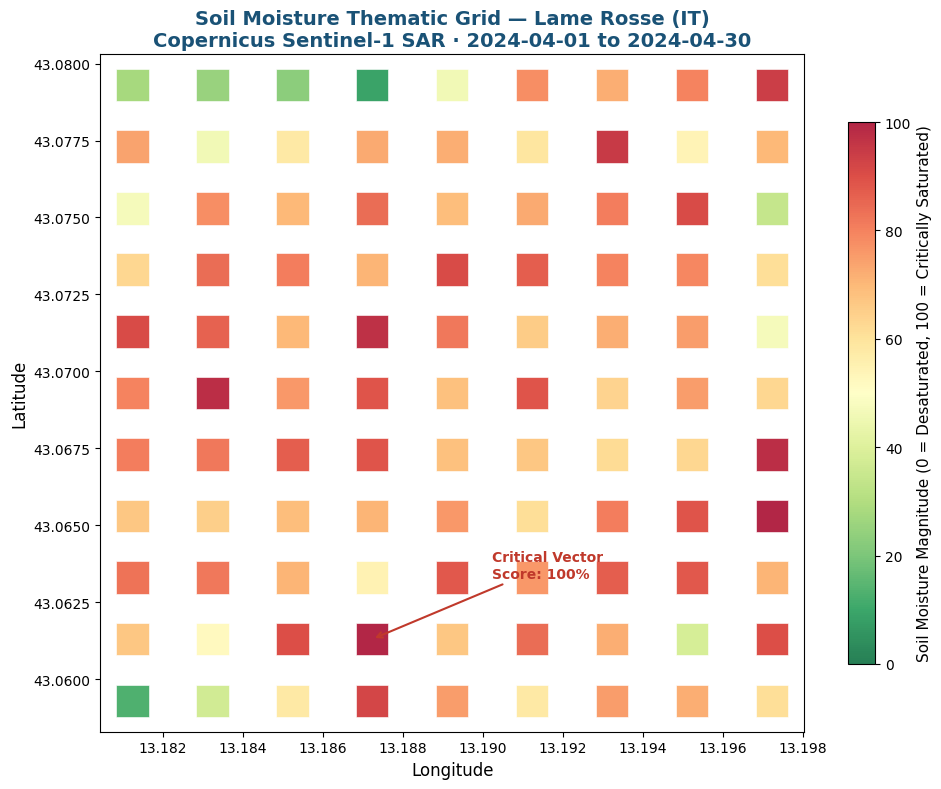

In [10]:
# Extract discrete spatial nodes and their corresponding moisture indices from the generated tensor
g_lats   = [p['lat']   for p in grid_points]
g_lngs   = [p['lng']   for p in grid_points]
g_scores = [p['score'] for p in grid_points]

fig, ax = plt.subplots(figsize=(10, 8))

# Render a thematic scatter plot highlighting subsurface moisture dynamics
# 'RdYlGn_r' colormap: Deep Green = Dry Baseline (Low Risk), Dark Red = Critically Saturated (High Risk)
scatter = ax.scatter(
    g_lngs, g_lats,
    c=g_scores,
    cmap='RdYlGn_r',
    vmin=0, vmax=100,
    s=550,          # Substantial cubic mass scaling to emulate continuous raster topography
    alpha=0.85,
    marker='s',     # Cubic geometry perfectly replicating satellite pixel fidelity
    edgecolors='white',
    linewidths=0.5  # Subtle bounding grid tracing
)

# Render an informative geoscientific colorbar diagnostic scale
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Soil Moisture Magnitude (0 = Desaturated, 100 = Critically Saturated)', fontsize=11)

# Annotate graphical spatial axes
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude',  fontsize=12)
ax.set_title(
    f'Soil Moisture Thematic Grid — Lame Rosse (IT)\n'
    f'Copernicus Sentinel-1 SAR · {wet_period[0]} to {wet_period[1]}',
    fontsize=14, fontweight='bold', color='#1A5276'
)

# Autonomously pinpoint and diagnose the most critical landslide risk vector dynamically
if grid_points:
    punto_critico = max(grid_points, key=lambda p: p['score'])
    ax.annotate(
        f"Critical Vector\nScore: {punto_critico['score']}%",
        xy=(punto_critico['lng'], punto_critico['lat']),
        xytext=(punto_critico['lng'] + 0.003, punto_critico['lat'] + 0.002), # Responsive micro-offset for tight BBox geometry
        fontsize=10, color='#C0392B', fontweight='bold',
        arrowprops=dict(arrowstyle='->', lw=1.5, color='#C0392B')
    )

# Format canvas and securely export graphical package
plt.tight_layout()
plt.savefig('lame_rosse_SAR_heatmap.png', dpi=150, bbox_inches='tight')
print('Heatmap geospatial visual successfully exported: lame_rosse_SAR_heatmap.png')
plt.show()